In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

Load Dataset

In [3]:
df = pd.read_csv('retail_large_dataset.csv')
df.head()

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No


In [3]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (100000, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   customer_id          100000 non-null  object 
 1   age                  100000 non-null  int64  
 2   gender               100000 non-null  object 
 3   city                 100000 non-null  object 
 4   state                100000 non-null  object 
 5   customer_segment     100000 non-null  object 
 6   order_id             100000 non-null  object 
 7   order_date           100000 non-null  object 
 8   product_category     100000 non-null  object 
 9   product_subcategory  100000 non-null  object 
 10  product_price        100000 non-null  int64  
 11  quantity             100000 non-null  int64  
 12  discount_percentage  100000 non-null  int64  
 13  final_price          100000 non-null  float64
 14  payment_method       100000 non-null  object 
 15

,age,product_price,quantity,discount_percentage,final_price,delivery_days
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.561830,30164.526720,2.501790,15.009890,64165.723382,5.505540
std,13.852439,17139.679807,1.120058,8.953296,49969.280150,2.872868
min,18.000000,500.000000,1.000000,0.000000,357.000000,1.000000
25%,30.000000,15375.000000,1.000000,7.000000,24705.000000,3.000000
50%,42.000000,30148.000000,3.000000,15.000000,49752.390000,5.000000
75%,54.000000,44957.000000,4.000000,23.000000,94046.070000,8.000000
max,65.000000,59998.000000,4.000000,30.000000,239980.000000,10.000000


In [5]:
# Convert date columns if any
for col in df.columns:
    if 'date' in col.lower():
        df[col] = pd.to_datetime(df[col], errors='coerce')

In [4]:
# Separate Columns
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical:", num_cols)
print("Categorical:", cat_cols)

Numerical: Index(['age', 'product_price', 'quantity', 'discount_percentage',
       'final_price', 'delivery_days'],
      dtype='object')
Categorical: Index(['customer_id', 'gender', 'city', 'state', 'customer_segment',
       'order_id', 'order_date', 'product_category', 'product_subcategory',
       'payment_method', 'shipping_type', 'return_status'],
      dtype='object')


UNIVARIATE ANALYSIS
Numerical Analysis

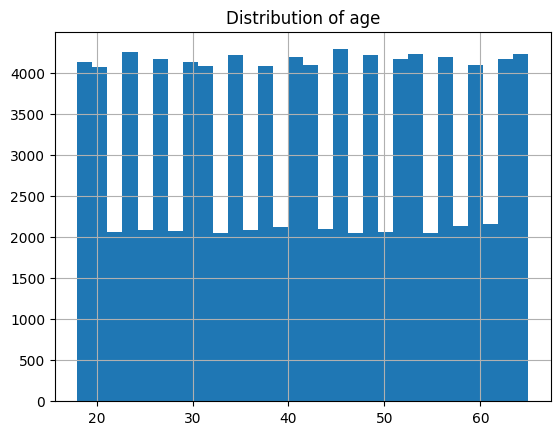

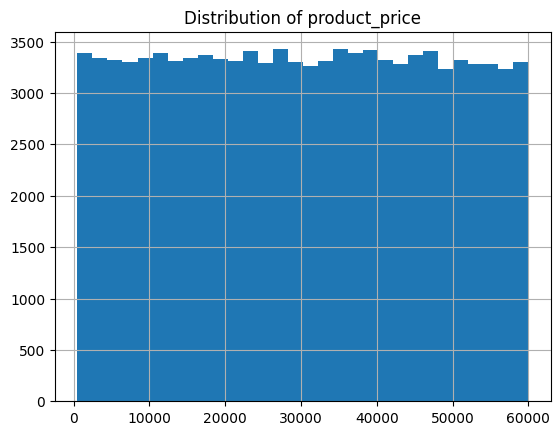

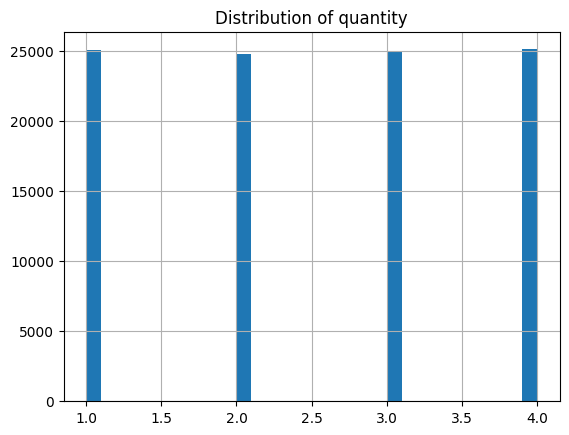

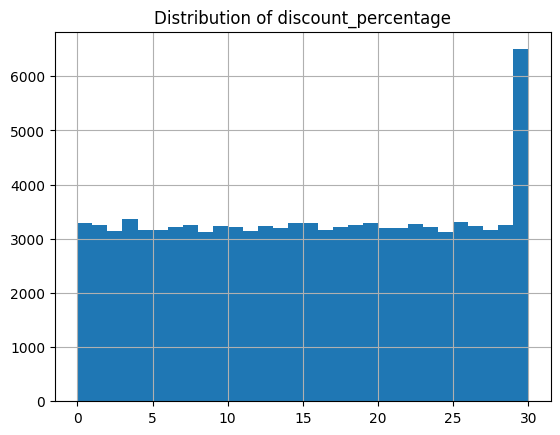

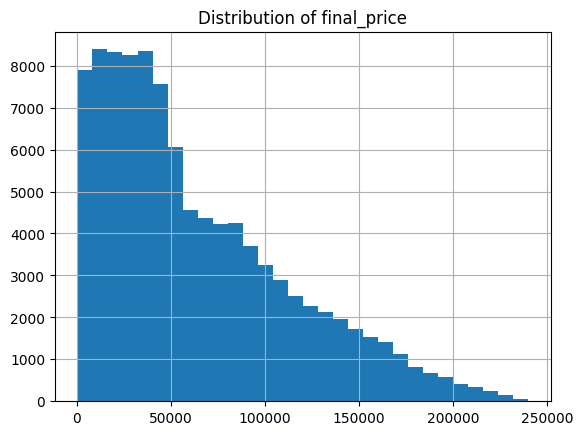

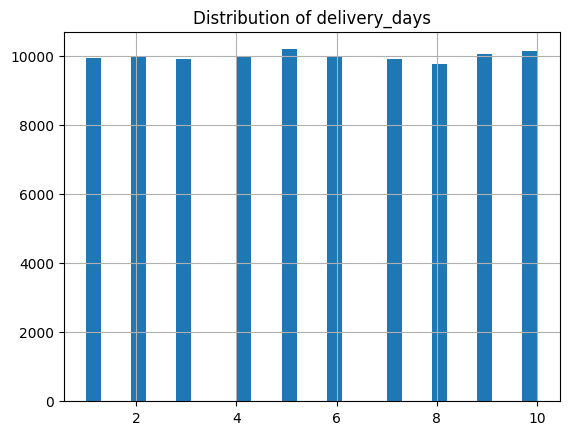

In [5]:
summary = []
for col in num_cols:
    stats = {
        'Column': col,
        'Mean': df[col].mean(),
        'Median': df[col].median(),
        'Std': df[col].std(),
        'Min': df[col].min(),
        'Max': df[col].max(),
        'Skewness': df[col].skew(),
        'Kurtosis': df[col].kurt()
    }
    summary.append(stats)
    
    plt.figure()
    df[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()
    pd.DataFrame(summary)

Insights (Numerical)
- Product price is positively skewed → more low-cost products
- Final price has high kurtosis → extreme transactions present
- Discount distribution is relatively uniform

In [5]:
# Categorical variables frequency distributions
for col in cat_cols:
    print(f"\n{'='*50}\n{col.upper()}\n{'='*50}")
    display(df[col].value_counts(dropna=False).head(10))


CUSTOMER_ID


customer_id
C10000    1
C10001    1
C10002    1
C10003    1
C10004    1
C10005    1
C10006    1
C10007    1
C10008    1
C10009    1
Name: count, dtype: int64


GENDER


gender
Male      50111
Female    49889
Name: count, dtype: int64


CITY


...

payment_method
Credit Card         25307
UPI                 25139
Cash on Delivery    24994
Debit Card          24560
Name: count, dtype: int64


SHIPPING_TYPE


shipping_type
Express     50008
Standard    49992
Name: count, dtype: int64


RETURN_STATUS


return_status
No     85189
Yes    14811
Name: count, dtype: int64

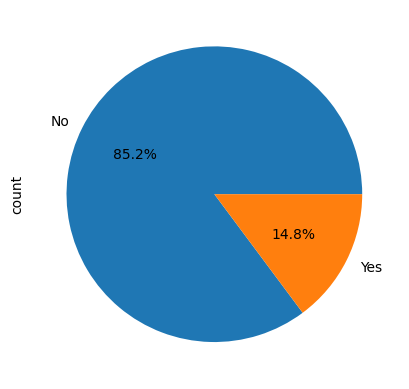

In [ ]:
# Categorical Analysis
df['return_status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.show()

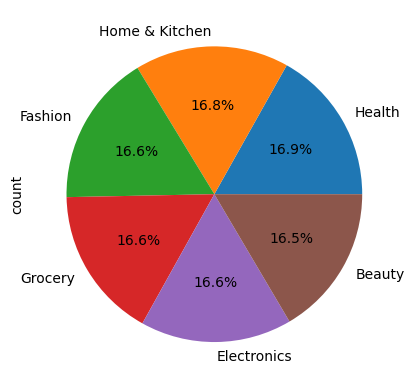

In [11]:
df['product_category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.show()

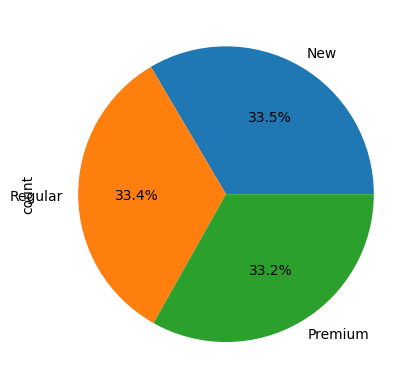

In [9]:
df['customer_segment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.show()

Insights (Categorical)
- Majority customers belong to Regular segment
- Electronic category dominates sales
- Return rate is around 15%

Skewness & Kurtosis Analysis

In [6]:
skew_kurt = pd.DataFrame({
    "Skewness": df[num_cols].skew(),
    "Kurtosis": df[num_cols].kurtosis()
})

skew_kurt.sort_values(by="Skewness", ascending=False)

,Skewness,Kurtosis
final_price,0.934747,0.169047
product_price,0.003249,-1.195106
delivery_days,0.002270,-1.221514
quantity,-0.003067,-1.364612
discount_percentage,-0.003597,-1.201628
age,-0.004988,-1.201172


Skewness & Kurtosis Dashboard

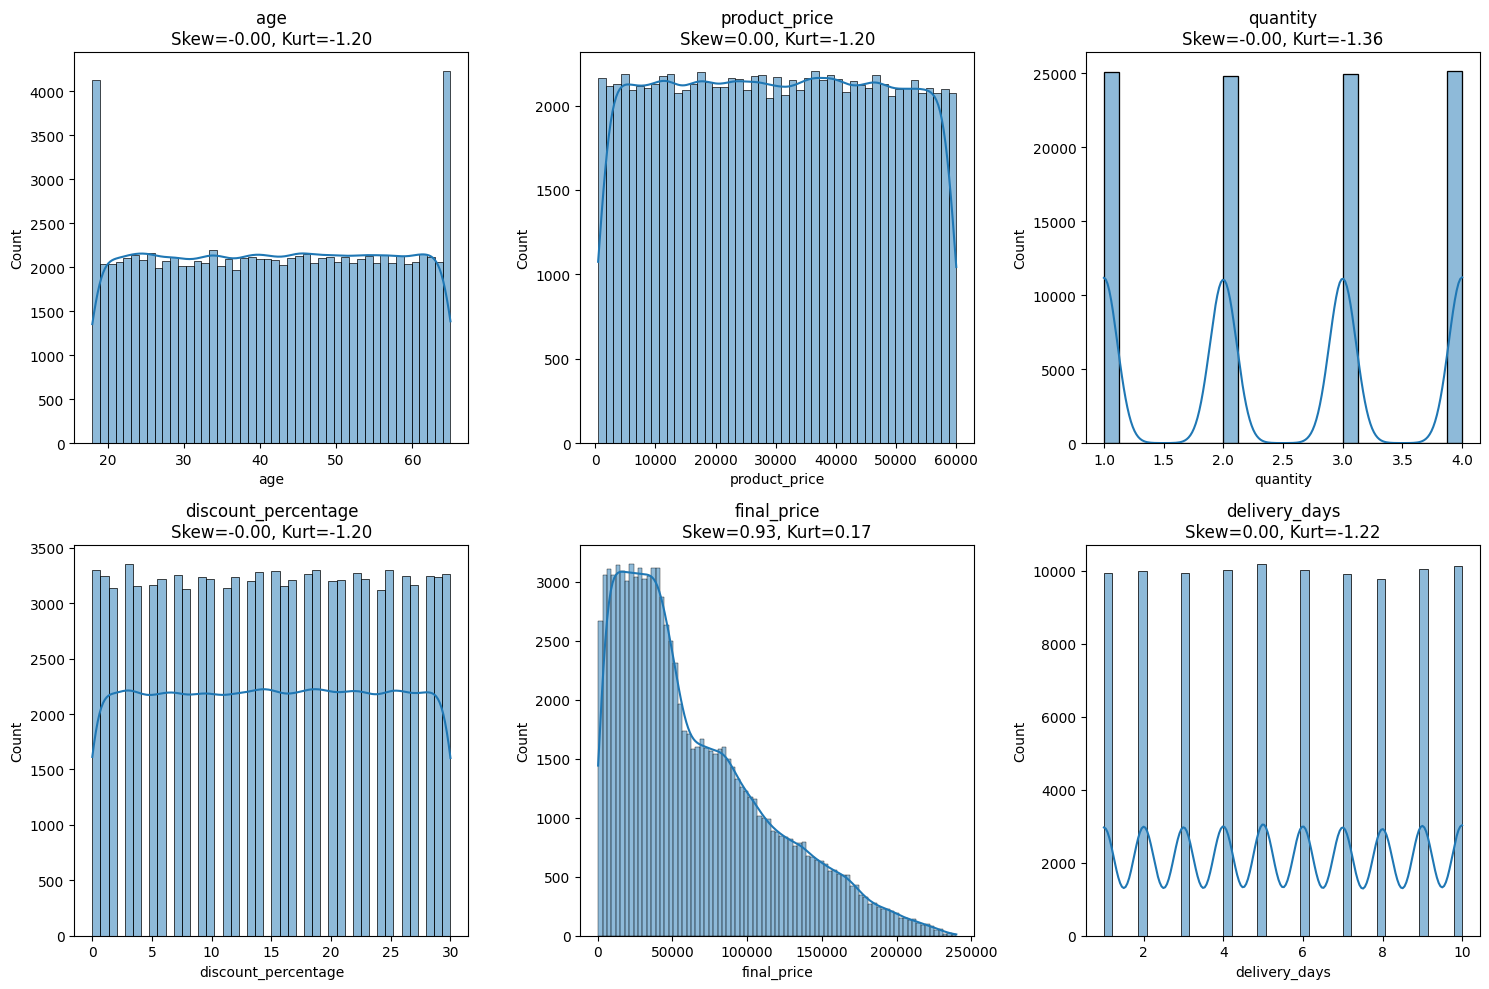

In [7]:
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols[:6], 1):
    plt.subplot(2,3,i)
    sns.histplot(df[col], kde=True)
    
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    
    plt.title(f"{col}\nSkew={skew:.2f}, Kurt={kurt:.2f}")

plt.tight_layout()
plt.show()

### Skewness
- Positive skew → more low values, few high values
- product_price & final_price are right-skewed


### Kurtosis
- High kurtosis → heavy tails (outliers present)


### Conclusion
- Revenue is not normally distributed
- High-value customers are critical

OUTLIER DETECTION

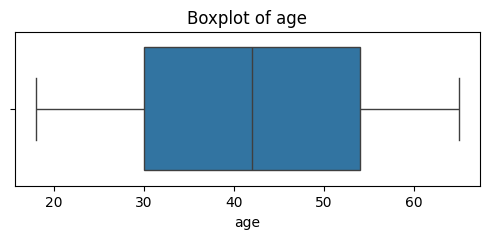

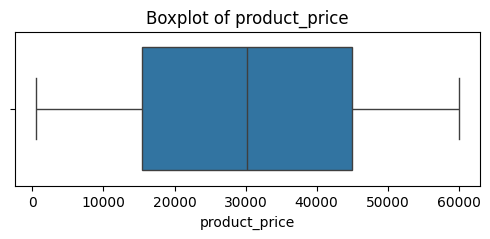

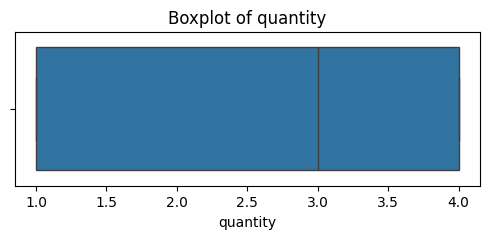

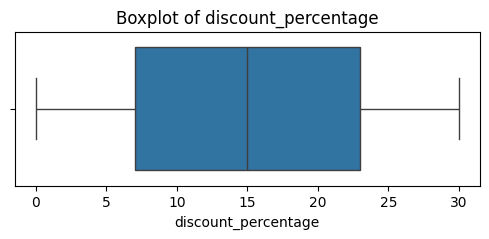

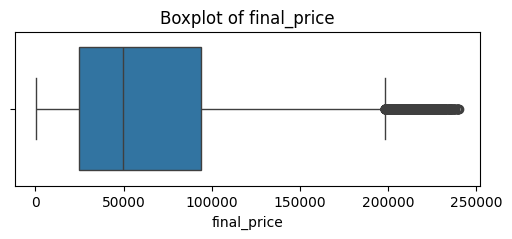

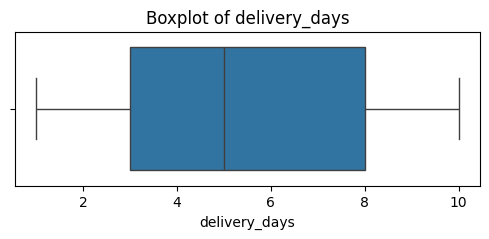

In [6]:
# Boxplot
for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [7]:
def detect_outliers_iqr(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)]

for col in num_cols:
    outliers = detect_outliers_iqr(col)
    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
product_price: 0 outliers
quantity: 0 outliers
discount_percentage: 0 outliers
final_price: 1335 outliers
delivery_days: 0 outliers


Insights (Outliers)
- Outliers present in product_price and final_price
- Represent bulk purchases and premium customers
- Should NOT be removed blindly

BIVARIATE ANALYSIS

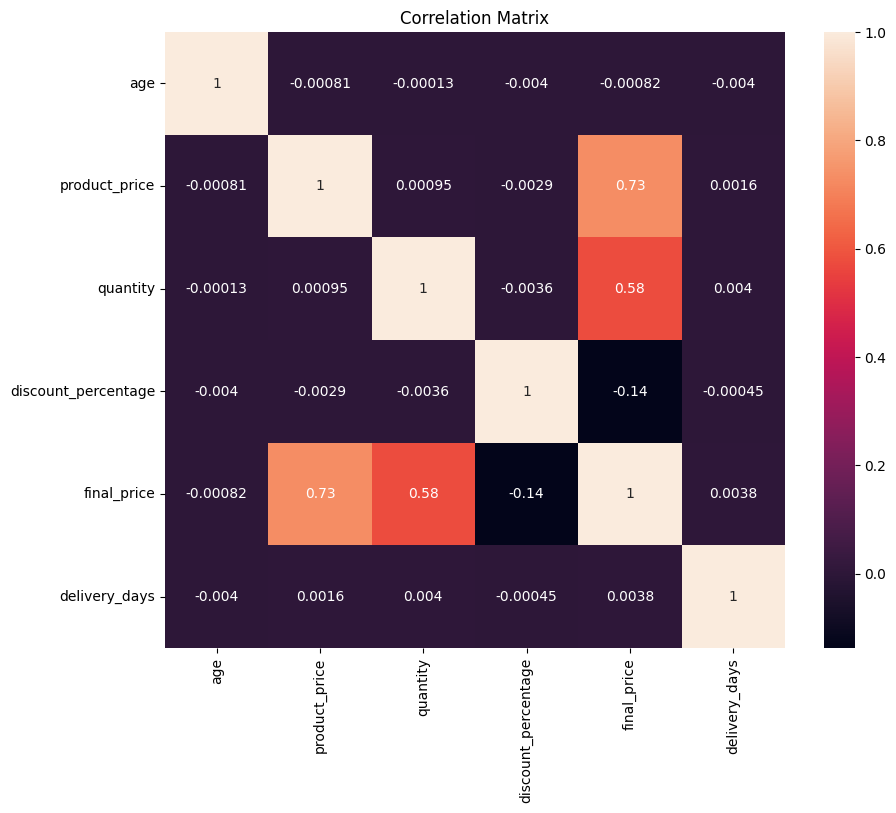

In [8]:
corr = df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

Insights (Correlation)
- Strong: product_price ↔ final_price
- Strong: quantity ↔ final_price
- Negative: discount ↔ revenue
- Weak: age ↔ spending

Numerical vs Categorical

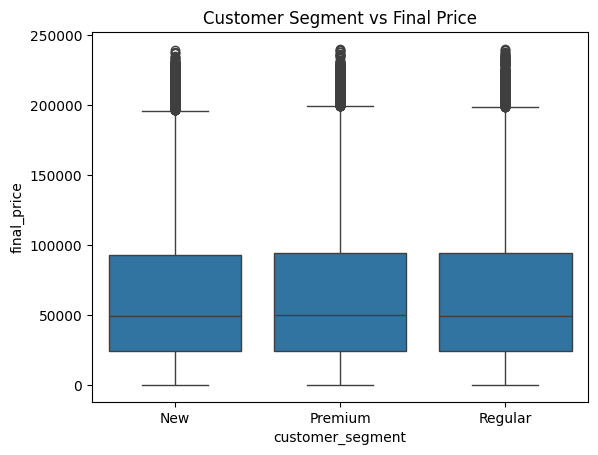

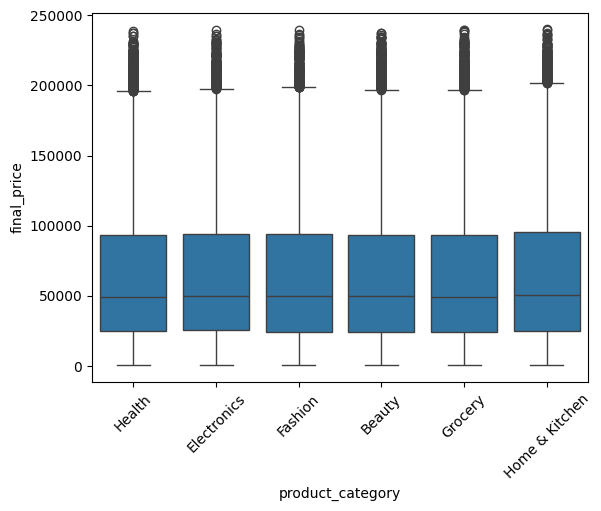

In [9]:
if 'customer_segment' in df.columns:
    sns.boxplot(x='customer_segment', y='final_price', data=df)
    plt.title("Customer Segment vs Final Price")
    plt.show()

if 'product_category' in df.columns:
    sns.boxplot(x='product_category', y='final_price', data=df)
    plt.xticks(rotation=45)
    plt.show()

Insights
- Premium customers spend more
- Electronics have higher returns
- Express shipping reduces delivery time

MULTIVARIATE ANALYSIS


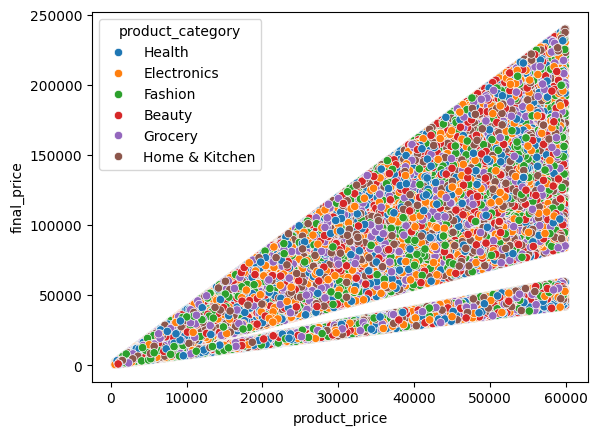

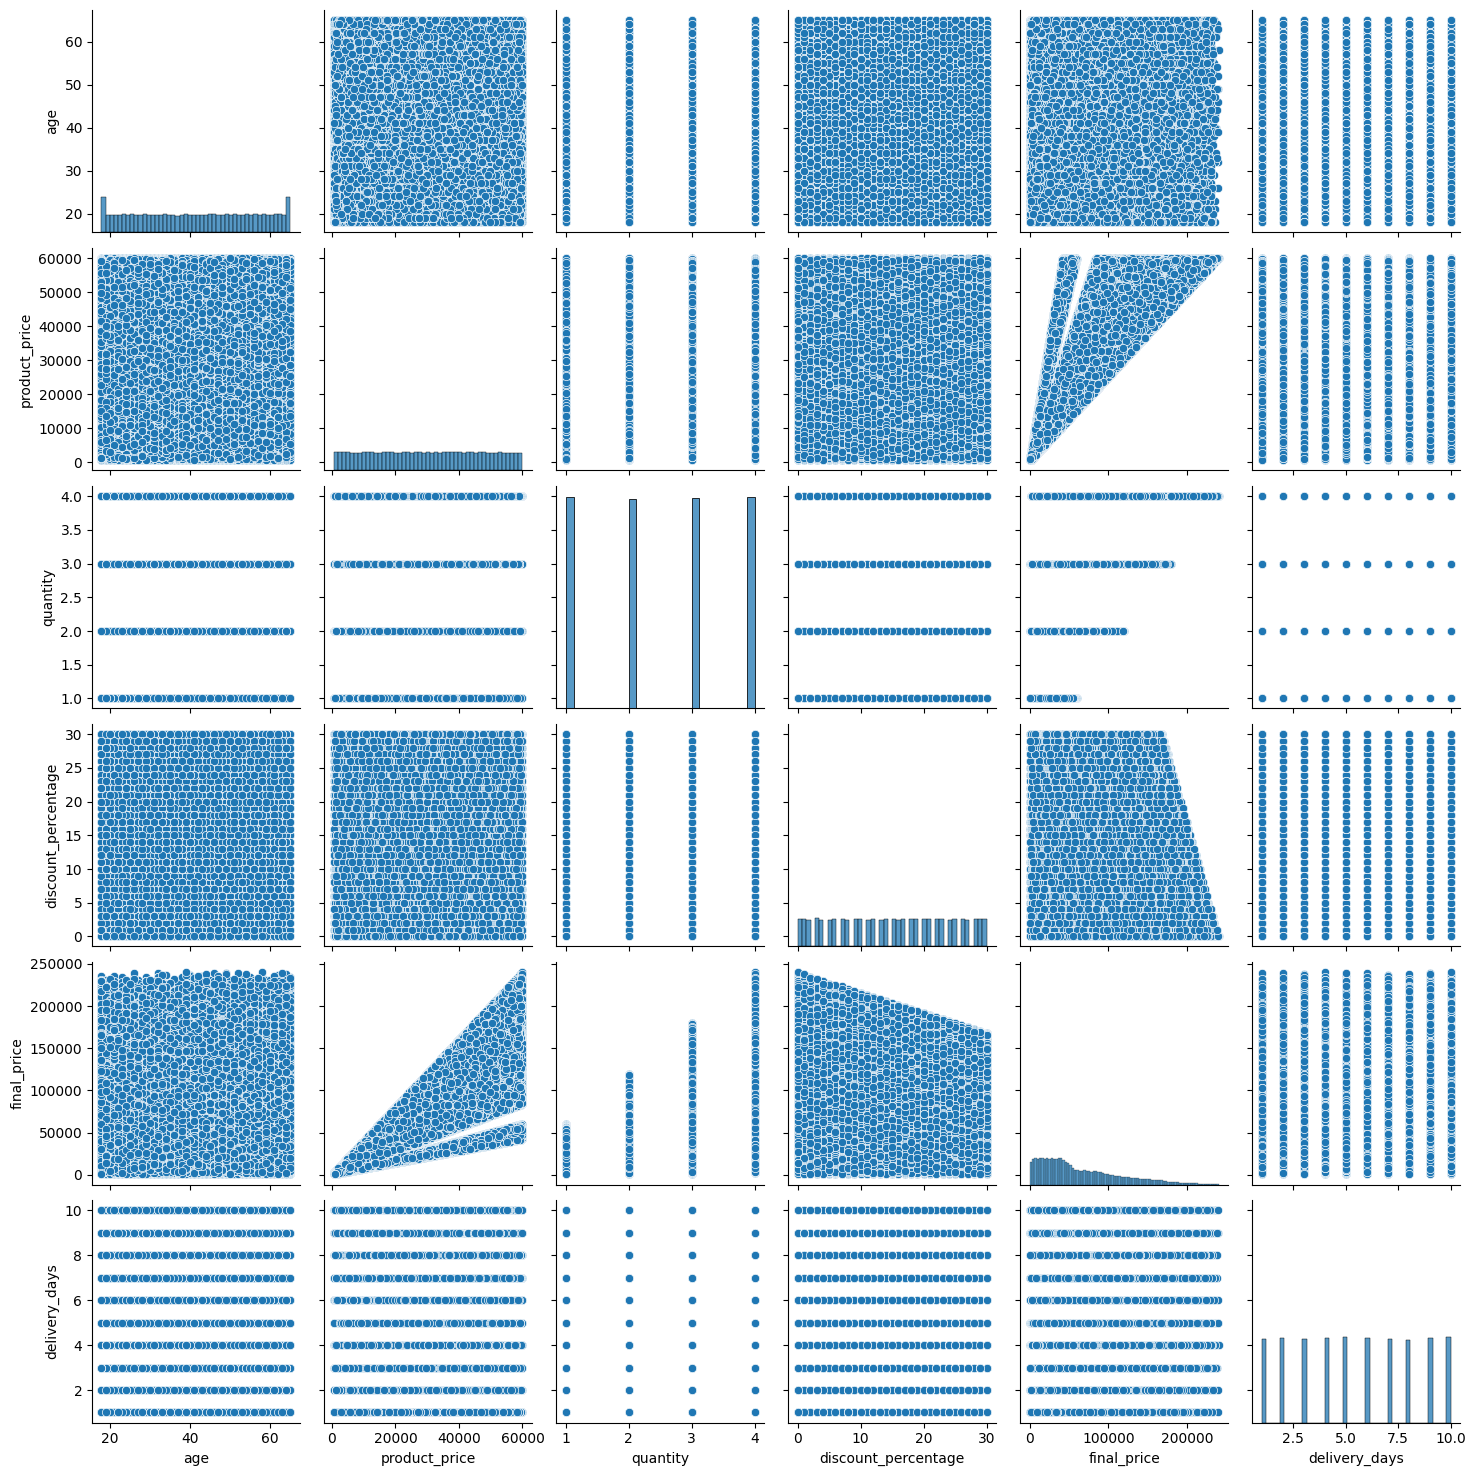

In [10]:
if 'product_price' in df.columns and 'final_price' in df.columns:
    sns.scatterplot(x='product_price', y='final_price', hue='product_category', data=df)
    plt.show()

sns.pairplot(df[num_cols])
plt.show()

Multivariate Insights
- Electronics + moderate discount → highest revenue
- Premium customers (age 30–45) spend most
- Longer delivery → higher return probability

Final Business Insights

- Revenue is right-skewed (few customers generate most revenue)
- Premium customers are key drivers of profit
- Moderate discounts maximize revenue
- Outliers represent high-value transactions
- Longer delivery increases return probability

## 📊 Recommendations
- Focus on premium customers
- Optimize discount strategy
- Improve delivery efficiency
- Reduce returns in electronics category